In [17]:
import rasterio
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score, jaccard_score
import matplotlib.pyplot as plt

In [18]:
# Define coordinates for Asia
asia_coordinates = {
    "lat_min": 1.0, "lat_max": 81.0,
    "lon_min": 25.0, "lon_max": 180.0
}

In [19]:
# Load raster file
file_path = "/content/global-grid-prob-urban-expansion-2030-wgs84.tif"

In [20]:
# Helper function to crop raster using bounding box
def crop_raster(file_path, coordinates):
    with rasterio.open(file_path) as src:

# Transform bounding box to pixel coordinates
        window = rasterio.windows.from_bounds(
            coordinates["lon_min"], coordinates["lat_min"],
            coordinates["lon_max"], coordinates["lat_max"],
            transform=src.transform
        )
        cropped_data = src.read(1, window=window)
        cropped_transform = src.window_transform(window)
    return cropped_data, cropped_transform

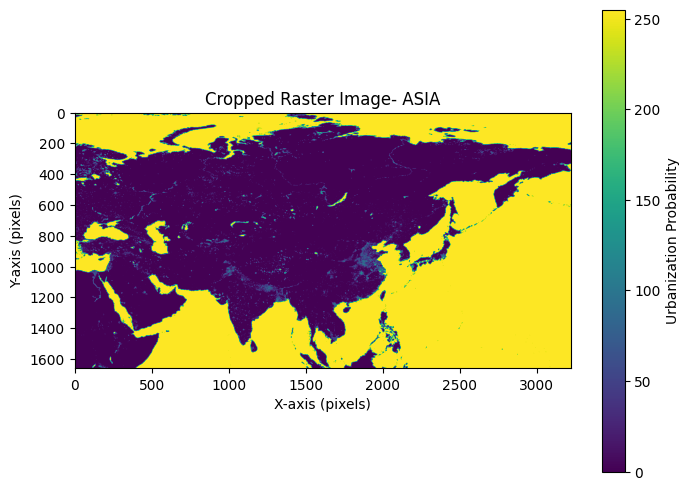

In [21]:
# Extract data for Asia
import matplotlib.pyplot as plt
asia_data, asia_transform = crop_raster(file_path, asia_coordinates)

#Visualise cropped data
plt.figure(figsize=(8, 6))
plt.imshow(asia_data, cmap='viridis')
plt.colorbar(label="Urbanization Probability")
plt.title("Cropped Raster Image- ASIA")
plt.xlabel("X-axis (pixels)")
plt.ylabel("Y-axis (pixels)")
plt.show()

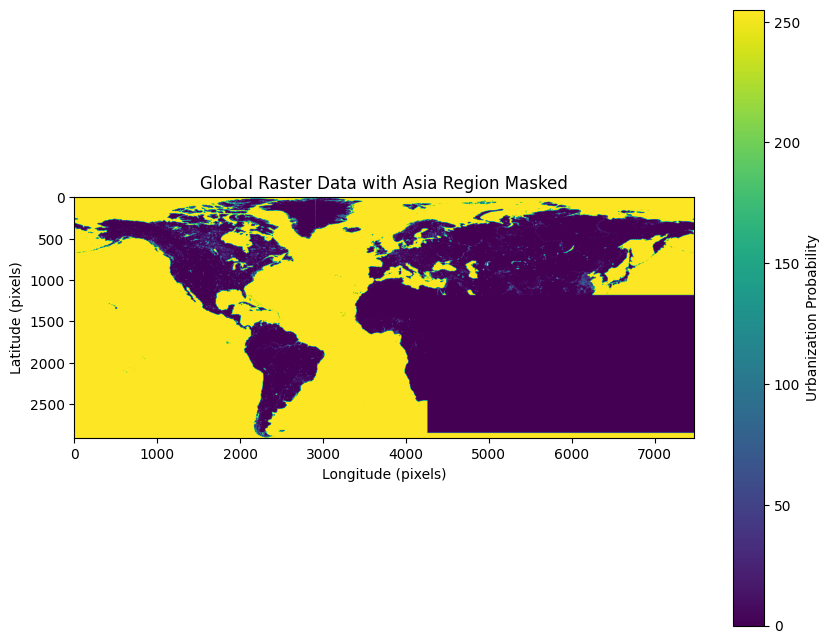

In [22]:
# Extract non-Asia data
with rasterio.open(file_path) as src:
    global_data = src.read(1)
non_asia_data = np.copy(global_data)
non_asia_data[
    int((asia_coordinates["lat_min"] - src.bounds.bottom) / src.res[1]):int((asia_coordinates["lat_max"] - src.bounds.bottom) / src.res[1]),
    int((asia_coordinates["lon_min"] - src.bounds.left) / src.res[0]):int((asia_coordinates["lon_max"] - src.bounds.left) / src.res[0])
] = 0

# Visualise Non asia data
plt.figure(figsize=(10, 8))
plt.imshow(non_asia_data, cmap='viridis')  # Use a suitable colormap
plt.colorbar(label="Urbanization Probability")
plt.title("Global Raster Data with Asia Region Masked")
plt.xlabel("Longitude (pixels)")
plt.ylabel("Latitude (pixels)")
plt.show()

In [23]:
# Helper function to create tiles
TILE_SIZE = 256
def create_patches(data, tile_size):
    patches = []
    for i in range(0, data.shape[0], tile_size):
        for j in range(0, data.shape[1], tile_size):
            patch = data[i:i + tile_size, j:j + tile_size]
            if patch.shape == (tile_size, tile_size):
                patches.append(patch)
    return np.array(patches)

In [24]:
# Preprocess non-Asia and Asia data
training_patches = create_patches(non_asia_data / 255.0, TILE_SIZE)  # Normalize
asia_patches = create_patches(asia_data / 255.0, TILE_SIZE)

In [25]:
# Add channel dimension
training_patches = training_patches[..., np.newaxis]
asia_patches = asia_patches[..., np.newaxis]

# Train-test split
x_train, x_val, y_train, y_val = train_test_split(
    training_patches, training_patches, test_size=0.2, random_state=42
)

In [26]:
# UNet Model Definition with reduced complexity
def unet_model(input_size=(256, 256, 1)):
    inputs = Input(input_size)
# Encoder
    conv1 = Conv2D(16, 3, activation='relu', padding='same')(inputs)
    conv1 = Conv2D(16, 3, activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(32, 3, activation='relu', padding='same')(pool1)
    conv2 = Conv2D(32, 3, activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(64, 3, activation='relu', padding='same')(pool2)
    conv3 = Conv2D(64, 3, activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(128, 3, activation='relu', padding='same')(pool3)
    conv4 = Dropout(0.3)(conv4)

# Decoder
    up5 = UpSampling2D(size=(2, 2))(conv4)
    up5 = concatenate([conv3, up5])
    conv5 = Conv2D(64, 3, activation='relu', padding='same')(up5)
    conv5 = Conv2D(64, 3, activation='relu', padding='same')(conv5)

    up6 = UpSampling2D(size=(2, 2))(conv5)
    up6 = concatenate([conv2, up6])
    conv6 = Conv2D(32, 3, activation='relu', padding='same')(up6)
    conv6 = Conv2D(32, 3, activation='relu', padding='same')(conv6)

    up7 = UpSampling2D(size=(2, 2))(conv6)
    up7 = concatenate([conv1, up7])
    conv7 = Conv2D(16, 3, activation='relu', padding='same')(up7)
    conv7 = Conv2D(16, 3, activation='relu', padding='same')(conv7)

    outputs = Conv2D(1, 1, activation='sigmoid')(conv7)
    return Model(inputs, outputs)

In [27]:
model = unet_model()
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 249s 30s/step - accuracy: 0.7262 - loss: 0.6667 - val_accuracy: 0.8519 - val_loss: 0.6559
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 250s 29s/step - accuracy: 0.8917 - loss: 0.6473 - val_accuracy: 0.8538 - val_loss: 0.6278
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 257s 28s/step - accuracy: 0.8656 - loss: 0.6081 - val_accuracy: 0.7901 - val_loss: 0.5745
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 275s 28s/step - accuracy: 0.8449 - loss: 0.5297 - val_accuracy: 0.8021 - val_loss: 0.4627
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 224s 28s/step - accuracy: 0.8786 - loss: 0.3888 - val_accuracy: 0.9118 - val_loss: 0.4141
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 281s 31s/step - accuracy: 0.9521 - loss: 0.3717 - val_accuracy: 0.9626 - val_loss: 0.3851
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 222s 28s/step - accuracy: 0.9710 - loss: 0.3596 - val_accuracy: 0.9733 - val_loss: 0.3617
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 252s 27s/step - accuracy: 0.9818 - loss: 0.3250 - val_accuracy: 0.9723 - val_loss:

In [28]:
# Predict for Asia
asia_predictions = model.predict(asia_patches)

3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step


In [29]:
# Reshape predictions and ground truth to calculate metrics
asia_true = (asia_patches.flatten() > 0.5).astype(int)  # Flatten and binarize ground truth
asia_pred = (asia_predictions.flatten() > 0.5).astype(int)  # Flatten predictions and binarize

# Calculate F1 Score
f1 = f1_score(asia_true, asia_pred)

# Calculate Jaccard Index (IoU)
jaccard = jaccard_score(asia_true, asia_pred)

print(f"F1 Score for Asia Predictions: {f1:.4f}")
print(f"Jaccard Index (IoU) for Asia Predictions: {jaccard:.4f}")

F1 Score for Asia Predictions: 0.9846
Jaccard Index (IoU) for Asia Predictions: 0.9696
